# 7 · Leaderboard final y conclusiones

Cierre: reunimos todos los modelos en un **leaderboard** y sacamos las conclusiones.
Incluimos **DeepSVDD** como referencia de un método moderno de deep anomaly detection
(librería `deepod`), a presupuesto parejo (300 épocas, capacidad como el VAE).

> **Sobre los métodos modernos:** probamos también ICL y NeuTraL, pero con presupuesto
> parejo dieron **por debajo del baseline** (ICL) o **cerca del azar** (NeuTraL) — no aportan
> a la comparación, así que dejamos solo DeepSVDD (el mejor de los tres). A DeepSVDD **sí lo
> tuneamos** (7.0) para que la comparación contra el VAE sea justa: el VAE tuvo su búsqueda de
> HP (nb 3), así que le damos a DeepSVDD la suya.

In [1]:
import lab                      # utilidades: métricas y gráficos (experiments/lab.py)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config, data
from src.models import (IsolationForestDetector, OneClassSVMDetector,
                        ZScoreDetector, MahalanobisDetector,
                        AEDetector, DenoisingAEDetector, VAEDetector,
                        EnsembleDetector, DeepODDetector)
plt.rcParams["figure.dpi"] = 110
SEEDS = lab.SEEDS            # 10 semillas del estudio. Bajalas (p. ej. [42,43,44])
print("semillas:", SEEDS)   # para un Run all más rápido; los números se mueven ±std

semillas: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


In [2]:
panel_z = data.prepare()                         # panel + etiqueta z_rinde
ds   = data.build_crop_dataset(panel_z, "soja")  # split + normalización (soja)
dsm  = data.build_crop_dataset(panel_z, "maiz")  # idem maíz
print("soja  train:", ds.X_train.shape, "| test anómalas:", int(ds.y_test.sum()))
print("maíz  train:", dsm.X_train.shape, "| test anómalas:", int(dsm.y_test.sum()))

[data] dedup panel: 27862 -> 20755 filas (7107 duplicados espurios por lat/lon eliminados)


soja  train: (6143, 65) | test anómalas: 251
maíz  train: (8082, 65) | test anómalas: 344


## 7.0 · Tuning de DeepSVDD (comparación justa)
Barrido chico de `lr`, `rep_dim` y `hidden_dims`, seleccionado **multi-seed** por
`media − std` (mismo criterio que el VAE en el nb 3: premia lo bueno *y* estable).
El resto (`epochs=300`, `batch_size=64`) queda a presupuesto parejo con el VAE.

In [3]:
DSVDD_GRID = [dict(lr=lr, rep_dim=rd, hidden_dims=hd)
              for lr in (1e-3, 5e-4) for rd in (16, 24) for hd in ("64,32", "128,64")]
filas_dsvdd = []
for cfg in DSVDD_GRID:
    prs = [lab.metrics(DeepODDetector(algo="deepsvdd", epochs=300, batch_size=64,
                       random_state=s, **cfg).fit(ds.X_train).score_samples(ds.X_test),
                       ds.y_test)["pr_auc"] for s in SEEDS[:3]]
    filas_dsvdd.append({**cfg, "pr_auc_mean": round(np.mean(prs), 3),
                        "pr_auc_std": round(np.std(prs), 3),
                        "media_menos_std": round(np.mean(prs) - np.std(prs), 3)})
dsvdd_hp = pd.DataFrame(filas_dsvdd).sort_values("media_menos_std", ascending=False).reset_index(drop=True)
DSVDD_BEST = dict(lr=float(dsvdd_hp.iloc[0]["lr"]), rep_dim=int(dsvdd_hp.iloc[0]["rep_dim"]),
                  hidden_dims=dsvdd_hp.iloc[0]["hidden_dims"])
print("DeepSVDD tuneado (mejor media−std):", DSVDD_BEST)
dsvdd_hp

DeepSVDD tuneado (mejor media−std): {'lr': 0.001, 'rep_dim': 24, 'hidden_dims': '64,32'}


,lr,rep_dim,hidden_dims,pr_auc_mean,pr_auc_std,media_menos_std
0,0.0010,24,"64,32",0.605,0.016,0.588
1,0.0010,16,"128,64",0.577,0.013,0.564
2,0.0005,24,"128,64",0.585,0.028,0.557
3,0.0005,16,"128,64",0.565,0.048,0.516
4,0.0005,24,"64,32",0.537,0.035,0.501
5,0.0010,24,"128,64",0.537,0.055,0.482
6,0.0005,16,"64,32",0.474,0.023,0.451
7,0.0010,16,"64,32",0.496,0.057,0.439


## 7.1 · Leaderboard final
Entrenamos cada modelo clave acá mismo, sobre el **panel unificado** (clima + NDVI + ERA5).
El **modelo final** es el seed-ensemble ×10 del VAE `recon_prob` (config ganadora
`(128,64) lat24`, nb 3). Todo multi-seed; OCSVM es determinista (std 0).

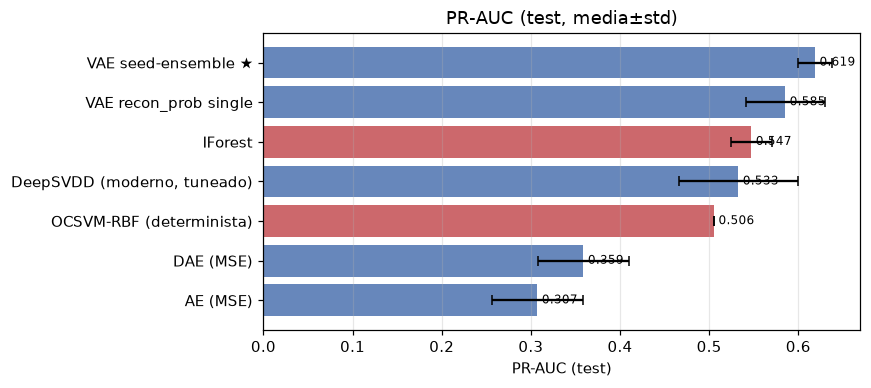

,modelo,pr_auc,pr_auc_std,roc_auc
0,VAE seed-ensemble ★,0.619,0.019,0.759
1,VAE recon_prob single,0.585,0.044,0.744
2,IForest,0.547,0.023,0.679
3,"DeepSVDD (moderno, tuneado)",0.533,0.066,0.756
4,OCSVM-RBF (determinista),0.506,0.000,0.700
5,DAE (MSE),0.359,0.051,0.607
6,AE (MSE),0.307,0.051,0.560


In [4]:
def ens_scores(dset, base):
    miembros = [VAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="recon_prob",
                n_mc_samples=50, max_epochs=300, patience=30, random_state=base+i) for i in range(10)]
    return EnsembleDetector(miembros).fit(dset.X_train).score_samples(dset.X_test)

lb = lab.leaderboard({
  "VAE seed-ensemble ★": [lab.metrics(ens_scores(ds, b), ds.y_test) for b in [42,52,62]],
  "VAE recon_prob single": [lab.metrics(VAEDetector(hidden_dims=(128,64), latent_dim=24,
        score_mode="recon_prob", n_mc_samples=50, max_epochs=300, patience=30, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "AE (MSE)": [lab.metrics(AEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="mse",
        max_epochs=300, patience=30, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "DAE (MSE)": [lab.metrics(DenoisingAEDetector(hidden_dims=(128,64), latent_dim=24, score_mode="mse",
        max_epochs=300, patience=30, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "IForest": [lab.metrics(IsolationForestDetector(n_estimators=200, max_features=0.3, random_state=s)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],   # estocástico → std
  "DeepSVDD (moderno, tuneado)": [lab.metrics(DeepODDetector(algo="deepsvdd", epochs=300,
        batch_size=64, random_state=s, **DSVDD_BEST)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test) for s in SEEDS],
  "OCSVM-RBF (determinista)": [lab.metrics(OneClassSVMDetector(kernel="rbf", nu=0.1)
        .fit(ds.X_train).score_samples(ds.X_test), ds.y_test)],                   # 1 corrida → std 0
})
lab.plot_leaderboard(lb); plt.show()
lb[["modelo","pr_auc","pr_auc_std","roc_auc"]].round(3)

## 7.2 · Recapitulación del recorrido
La historia en una tabla. Los **PR-AUC salen del leaderboard vivo de arriba** (`lb`, celda
7.1) — no hay ningún número escrito a mano: si cambiás las semillas o el pipeline, esta tabla
se mueve sola con la corrida.

In [5]:
pr = dict(zip(lb["modelo"], lb["pr_auc"]))   # PR-AUC reales, tomados del leaderboard 7.1
recap = pd.DataFrame([
    ("nb1", "Isolation Forest (baseline)",        pr["IForest"],                       "listón no neuronal, varianza baja"),
    ("nb1", "One-Class SVM (RBF)",                pr["OCSVM-RBF (determinista)"],       "kernel gaussiano ≈ IForest; el lineal fracasa (nb1)"),
    ("nb2", "AE (score MSE)",                     pr["AE (MSE)"],                       "el MSE plano no alcanza"),
    ("nb2", "DAE (score MSE)",                    pr["DAE (MSE)"],                      "el denoising no cambia el cuello de botella"),
    ("nb3", "VAE recon_prob (single)",            pr["VAE recon_prob single"],          "el SCORE probabilístico es el salto vs MSE"),
    ("nb4", "VAE seed-ensemble ×10 ★",            pr["VAE seed-ensemble ★"],            "MODELO FINAL: baja la varianza y sube la media"),
    ("nb7", "DeepSVDD (moderno, tuneado)",        pr["DeepSVDD (moderno, tuneado)"],    "tuneado (7.0) y a presupuesto parejo, por debajo del VAE"),
], columns=["nb", "etapa", "PR-AUC soja (test)", "conclusión"])
recap["PR-AUC soja (test)"] = recap["PR-AUC soja (test)"].round(3)
recap

,nb,etapa,PR-AUC soja (test),conclusión
0,nb1,Isolation Forest (baseline),0.547,"listón no neuronal, varianza baja"
1,nb1,One-Class SVM (RBF),0.506,kernel gaussiano ≈ IForest; el lineal fracasa ...
2,nb2,AE (score MSE),0.307,el MSE plano no alcanza
3,nb2,DAE (score MSE),0.359,el denoising no cambia el cuello de botella
4,nb3,VAE recon_prob (single),0.585,el SCORE probabilístico es el salto vs MSE
5,nb4,VAE seed-ensemble ×10 ★,0.619,MODELO FINAL: baja la varianza y sube la media
6,nb7,"DeepSVDD (moderno, tuneado)",0.533,"tuneado (7.0) y a presupuesto parejo, por deba..."


## Conclusiones del Componente A
1. **Modelo final: seed-ensemble ×10 del VAE `recon_prob`** sobre el panel unificado (clima
   + NDVI + ERA5) — el mejor del leaderboard de arriba (7.1) y con el menor desvío.
2. **Dos decisiones** lo explican: el **score probabilístico** `recon_prob` (aplasta al MSE,
   nb 3) y el **ensemble de semillas** que baja fuerte la varianza (nb 4). El panel ya trae
   suelo + verdor (NDVI/ERA5), que corren el techo un poco (mejora chica pero real; por eso
   quedaron en el dataset).
3. **Lección metodológica central:** reportar la varianza multi-seed no es un detalle — sin
   ella, mejoras chicas (como la de suelo+verdor) quedan enterradas en el ruido de los
   modelos single.
4. Alternativas refutadas: AE/DAE con MSE, detectores sobre el latente (nb 2–4), las features
   `agro` de dominio (nb 6), y el deep AD moderno tuneado a presupuesto parejo (nb 7).
5. **Techo estructural (nb 5):** existe (rondamos ~0.6), la mayoría de las anomalías siguen
   sin firma observable. Superarlo más requeriría **feature engineering más rico** (nb 6) u
   **otra clase de datos** (sanidad, granizo, manejo).